### **CN2 Algorithm**

The **CN2 algorithm** is a classification rule learning algorithm that induces a set of classification rules from a given set of training examples. It was developed by Peter Clark and Tim Niblett in 1989 as an improvement over earlier rule induction systems, particularly those based on the AQ algorithm family.

The fundamental purpose of CN2 is to discover simple, comprehensible, and accurate classification rules from data. In the context of rule induction, a 'rule' typically takes the form of 'IF [conditions] THEN [class]', where the conditions are tests on attribute values and the class is the predicted outcome. CN2 aims to find rules that cover a significant number of positive examples while covering as few negative examples as possible.

Its primary applications include:
*   **Classification:** Predicting the class label of new, unseen instances.
*   **Knowledge Discovery:** Extracting understandable patterns and relationships from large datasets, which can be valuable for human interpretation and decision-making.
*   **Expert Systems:** Providing a basis for building rule-based expert systems.

CN2 is particularly valued for generating rules that are both accurate and easy for humans to understand, contrasting with 'black-box' models like some neural networks.

### **The Iterative Process of the CN2 Algorithm**

#### 1. Rule Discovery (Finding the 'Best' Rule)
*   **Initial Rule Set:** Start with an empty set of rules.
*   **Search for Candidates:** In each iteration, CN2 generates a set of candidate rules.
*   **Evaluation Metric:** Each candidate rule is evaluated based on a specific quality metric. Common metrics include: **Likeliness Ratio Statistic (LRS)**, **Entropy**, **Statistical Significance Test**, and **Best Rule Selection**.

#### 2. Example Covering
Once a 'best' rule has been discovered and added to the rule set, the principle of example covering is applied. This step is crucial for the iterative nature of CN2 and for preventing redundant rules: **Removal of Covered Examples** and **Focus on Remaining Examples**.

#### 3. Termination Conditions
The iterative process of rule discovery and example covering continues until one or more termination conditions are met. These conditions prevent the algorithm from generating an infinite number of rules or rules that are not meaningful: **No Statistically Significant Rules**, **Empty Dataset**, **Minimum Number of Examples**,   **Coverage Threshold**, and **Maximum Number of Rules**.

### **CN2 Rule Generation: Search Strategy, Evaluation, and Overfitting Prevention**

CN2 is a classic rule induction algorithm that generates a set of 'if-then' rules from data. It is particularly known for its ability to handle noisy data and for using a greedy search combined with statistical testing to prevent overfitting.

#### 1. Search Strategy: Beam Search

CN2 typically employs a **beam search** algorithm to find the best rules. Unlike a simple greedy search that explores only the single best path, beam search maintains a fixed-size 'beam' of the `k` most promising partial rules at each step. Here's how it generally works:

#### 2. Evaluation Functions

To assess the quality of candidate rules, CN2 uses evaluation functions that quantify how well a rule predicts the target class and how much information it provides. Common evaluation functions include: **Laplace Accuracy (or Laplace Estimate)**, **Entropy (Information Gain)**, and **Likelihood Ratio Statistic**.

#### 3. Statistical Significance Tests for Overfitting Prevention

Overfitting occurs when a model learns the training data too well, including its noise and outliers, leading to poor performance on unseen data. CN2 incorporates statistical significance tests primarily to avoid generating overly specific or spurious rules: **Chi-squared ($\chi^2$) Test or Likelihood Ratio Test** and **Significance Threshold**.

In [ ]:
#Install Orange Library
!pip install orange3;

In [2]:
#Import Libs
from Orange.classification import CN2Learner
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import Orange

In [3]:
# Load the dataset
data = Orange.data.Table('https://raw.githubusercontent.com/jrafa1607/DataScience-ML-AI/main/-%20Datasets/diabetes.csv')

In [4]:
#Show the First 5 rows of the data table
for i, row in enumerate(data[:5]):
    print(row)

[6, 148, 72, 35, 0, 33.6, 0.627, 50, 1]
[1, 85, 66, 29, 0, 26.6, 0.351, 31, 0]
[8, 183, 64, 0, 0, 23.3, 0.672, 32, 1]
[1, 89, 66, 23, 94, 28.1, 0.167, 21, 0]
[0, 137, 40, 35, 168, 43.1, 2.288, 33, 1]


In [5]:
# nitiate CN2Learner ( Beam is the default rule_finder for CN2Learner )
cn2_learner = CN2Learner()

In [6]:
#Train the CN2Model
all_attributes = list(data.domain.attributes)

In [7]:
# Remove the last attribute [ Class ] from the list
class_attribute_candidate = all_attributes.pop()

In [8]:
# Create a new discrete variable for the class and a new domain
new_class_var = Orange.data.DiscreteVariable(class_attribute_candidate.name, values=["0", "1"])
new_domain = Orange.data.Domain(all_attributes, new_class_var)

In [9]:
# Use Table.from_table to avoid the DeprecationWarning and Train the CN2Model
data = Orange.data.Table.from_table(new_domain, data)
cn2_model = cn2_learner(data)

In [10]:
#Show the generated rules
for rule in cn2_model.rule_list:
    print(rule)

IF BMI<=27.9 AND SkinThickness>=39.0 THEN Outcome=1 
IF Glucose>=155.0 AND SkinThickness>=45.0 THEN Outcome=1 
IF Insulin<=122.0 AND BMI>=47.9 THEN Outcome=1 
IF Glucose>=155.0 AND BMI>=46.5 THEN Outcome=0 
IF Glucose>=155.0 AND Pregnancies>=11.0 THEN Outcome=1 
IF BMI<=27.4 AND Glucose<=106.0 AND BloodPressure>=62.0 THEN Outcome=0 
IF Age<=29.0 AND BloodPressure>=110.0 THEN Outcome=1 
IF DiabetesPedigreeFunction<=0.528 AND Insulin>=474.0 THEN Outcome=1 
IF Glucose>=155.0 AND SkinThickness>=44.0 THEN Outcome=0 
IF Glucose<=100.0 AND BMI<=27.6 AND SkinThickness>=10.0 THEN Outcome=0 
IF Age<=29.0 AND BloodPressure>=94.0 THEN Outcome=0 
IF SkinThickness<=32.0 AND Insulin>=478.0 THEN Outcome=1 
IF Glucose<=100.0 AND Age<=26.0 AND Pregnancies>=4.0 THEN Outcome=0 
IF Glucose<=124.0 AND BMI<=26.5 AND BloodPressure>=64.0 THEN Outcome=0 
IF Glucose<=112.0 AND BMI<=26.5 AND Insulin>=56.0 THEN Outcome=0 
IF BMI<=29.9 AND Age>=63.0 THEN Outcome=0 
IF SkinThickness>=52.0 THEN Outcome=0 
IF Glucose>

In [11]:
#Get the Classes Information
predicted_probabilities = cn2_model.predict_proba(data.X)
predicted_classes_idx = np.argmax(predicted_probabilities, axis=1)
true_classes = data.Y.astype(int)

In [12]:
# Get class labels from the dataset
class_labels = data.domain.class_var.values

In [13]:
#Show the Accuracy of the Set of Rules
overall_accuracy = accuracy_score(true_classes, predicted_classes_idx)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Overall Accuracy: 1.0000


In [14]:
# Calculate the Precision, Recall, and F1-score for Each Class
for i, label in enumerate(class_labels):
    precision = precision_score(true_classes, predicted_classes_idx, pos_label=i, average='binary')
    recall = recall_score(true_classes, predicted_classes_idx, pos_label=i, average='binary')
    f1 = f1_score(true_classes, predicted_classes_idx, pos_label=i, average='binary')

    print(f"\nClass '{label}' (Target {i}):")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")


Class '0' (Target 0):
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Class '1' (Target 1):
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000


In [15]:
#Calculate the Confusion Matrix
conf_mat = confusion_matrix(true_classes, predicted_classes_idx)
class_labels = data.domain.class_var.values

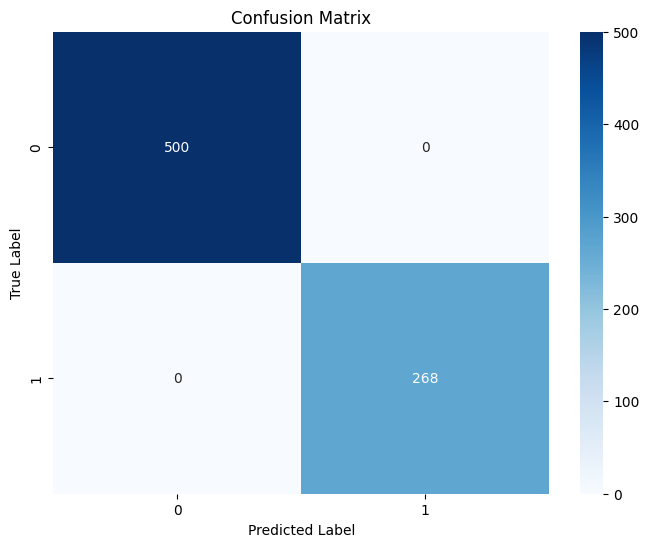

In [16]:
#Show the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [17]:
# Calculate ROC Curve
positive_class_probabilities = predicted_probabilities[:, 1]

# fpr = False Positive Rate
# tpr = True Positive Rate
# thresholds = Thresholds used to compute fpr and tpr
fpr, tpr, thresholds = roc_curve(true_classes, positive_class_probabilities)

# Calculate AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)
print(f"Area Under the Curve (AUC): {roc_auc:.4f}")

Area Under the Curve (AUC): 1.0000


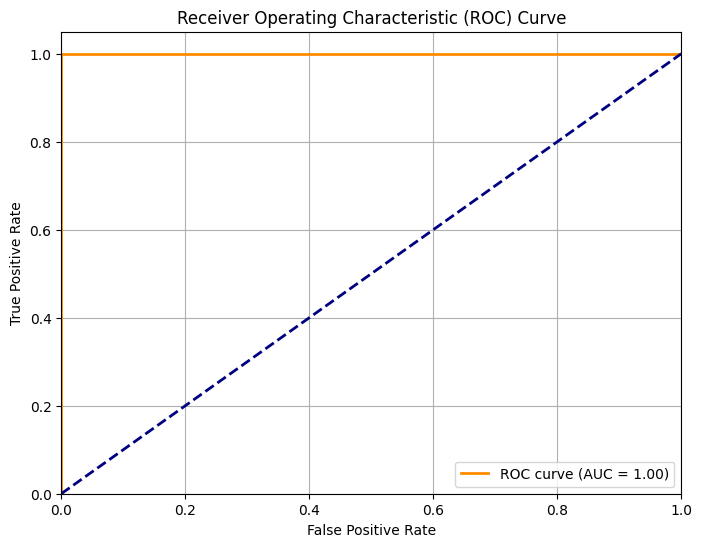

In [18]:
#Show the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()